In [1]:
import utils
import numpy as np
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

pd.set_option('display.max_columns', None)

# Exclusion criteria
- Check only the last two blocks
- cutoff for congruent = 60%
- cutoff for incongruent = 100% - congruent + 10%

In [2]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [39]
unique_sessions = [2]
use_second_block = False

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, remove_reversals=True)

These participants will be excluded: {'sub-059_session-03'}



# Check whether they get tired

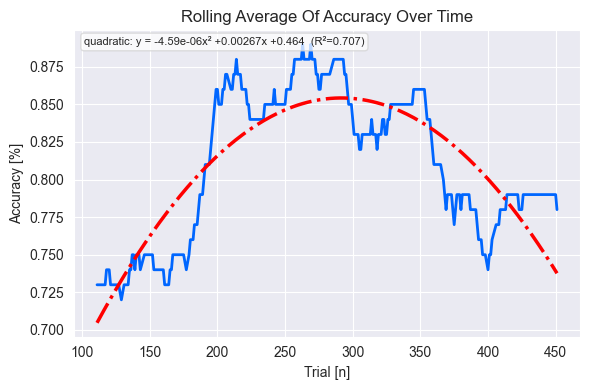

In [3]:
combined_results_dataframe['objectively_correct_rolling_average'] = combined_results_dataframe['objectively_correct_boolean'].rolling(window=100).mean()

utils.plotting_functions.lineplot_se(
    df=combined_results_dataframe,
    x_col='trial', y_col='objectively_correct_rolling_average',
    xlabel_name='trial [n]', ylabel_name='accuracy [%]',
    subject_col='subject_id',
    legend_outside=True,
    trend=['quadratic'], show_trend_stats=True, trend_colour='red',
    plot_name='rolling average of accuracy over time',
    save=False
);

# Remove everything but the last two blocks

In [4]:
# Create a helper column that increments whenever the value changes.
# This assigns a unique group number to each contiguous block.
last_block_stimulus_1 = combined_results_dataframe[combined_results_dataframe['stimuli_type'] == 1]
last_block_stimulus_2 = combined_results_dataframe[combined_results_dataframe['stimuli_type'] == 2]
last_block_stimulus_1['group'] = (last_block_stimulus_1['volatility'] != last_block_stimulus_1['volatility'].shift()).cumsum()
last_block_stimulus_2['group'] = (last_block_stimulus_2['volatility'] != last_block_stimulus_2['volatility'].shift()).cumsum()

# Get the top two values from the "group" column
unique_groups = last_block_stimulus_1['group'].unique()
if use_second_block:
    top_two = sorted(unique_groups, reverse=True)[2:4]
else:
    top_two = sorted(unique_groups, reverse=True)[:2]
print(top_two)
# Filter the DataFrame to include only rows with these top two values
last_block_stimulus_1 = last_block_stimulus_1[last_block_stimulus_1['group'].isin(top_two)]
# Get the top two values from the "group" column
unique_groups = last_block_stimulus_2['group'].unique()
if use_second_block:
    top_two = sorted(unique_groups, reverse=True)[2:4]
else:
    top_two = sorted(unique_groups, reverse=True)[:2]
print(top_two)
# Filter the DataFrame to include only rows with these top two values
last_block_stimulus_2 = last_block_stimulus_2[last_block_stimulus_2['group'].isin(top_two)]

frames = [last_block_stimulus_1, last_block_stimulus_2]

last_block_stimulus = pd.concat(frames)

last_blocks_results = last_block_stimulus.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])
# Reset the index
last_blocks_results.reset_index(drop=True, inplace=True)

# Filter to keep only rows that belong to these last blocks
print(last_blocks_results[['trial','stimuli_type','volatility','group']])
last_blocks_results.drop(columns='group', inplace=True)

[5, 4]
[5, 4]
     trial  stimuli_type volatility  group
0      248             1     stable      4
1      250             1     stable      4
2      253             1     stable      4
3      254             1     stable      4
4      257             1     stable      4
..     ...           ...        ...    ...
182    443             2   volatile      5
183    444             2   volatile      5
184    447             2   volatile      5
185    449             2   volatile      5
186    450             2   volatile      5

[187 rows x 4 columns]


/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5032/4119392886.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_block_stimulus_1['group'] = (last_block_stimulus_1['volatility'] != last_block_stimulus_1['volatility'].shift()).cumsum()
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5032/4119392886.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  last_block_stimulus_2['group'] = (last_block_stimulus_2['volatility'] != last_block_stimulus_2['volatility'].shift()).cumsum()


In [5]:
# Create new plots with different intervals that also contain the 50% trials
print(last_blocks_results)
unique_stimuli_types = last_blocks_results['stimuli_type'].unique()
mapping = {0: 'subject_id', 1: 'stimuli_type', 2: 'congruency', 3: 0, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5, 9: 6}
group_name = 'congruency'
session_name = 'session'
unique_group_types = last_blocks_results[group_name].unique()


all_reversals_dataframe = utils.analysis_functions.find_reversals_in_dataframe(last_blocks_results,
                                                                             unique_subject_ids, unique_stimuli_types,
                                                                             group_name, plot_range, mapping, session_name)
participant_excluded = False
print(all_reversals_dataframe)

     trial  emotional_cue_time  response objectively_correct  \
0      248        1.787065e+09     avoid                True   
1      250        1.787065e+09     avoid                True   
2      253        1.787065e+09     avoid                True   
3      254        1.787065e+09     avoid                True   
4      257        1.787065e+09     avoid                True   
..     ...                 ...       ...                 ...   
182    443        1.787065e+09  approach                True   
183    444        1.787065e+09  approach                True   
184    447        1.787065e+09  approach                True   
185    449        1.787065e+09  approach                True   
186    450        1.787065e+09  approach                True   

    subjectively_correct  response_time   RT_s  feedback_time  stimuli_type  \
0                   True   1.787065e+09  0.628   1.787065e+09             1   
1                   True   1.787065e+09  0.571   1.787065e+09            

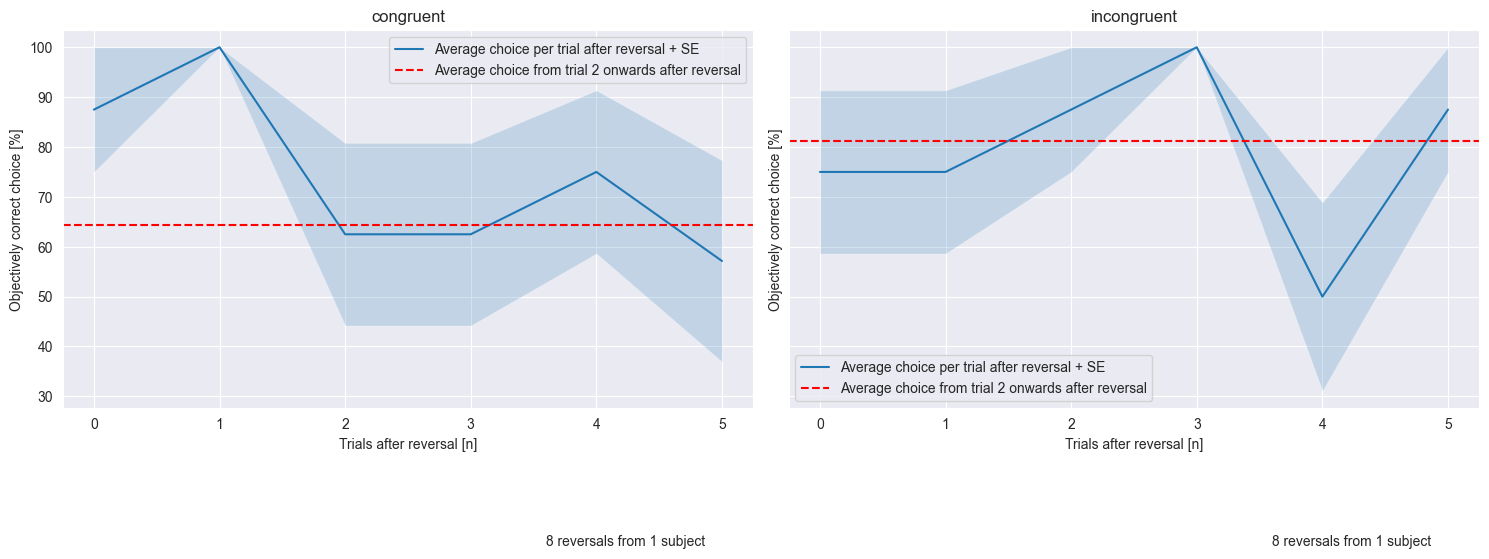

In [6]:
# Prepare the DataFrame by setting 'stimuli_type' as the index temporarily
df = all_reversals_dataframe.set_index('congruency')

subject_counts = len(df['subject_id'].unique())

# Count the number of times both conditions were shown
group_counts = df.index.value_counts()

# We are not using 'subject_id', so let's exclude it from our calculations
df = df.drop(columns=['subject_id'])
df = df.drop(columns=['stimuli_type'])
df = df.drop(columns=['session'])

# Calculate the mean and standard deviation for each timepoint and stimuli_type
means = df.groupby('congruency').mean()
means = means*100
means_overall = means.iloc[:, 2:]
average_choice_after_reversal_total = means_overall.mean(axis=1).tolist()
stds = df.groupby('congruency').sem()
stds = stds * 100

# Plotting
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharex=False, sharey=True) # Adjust based on the number of stimuli_types
axs = axs.flatten() # Flatten to iterate easily

#fig.suptitle('Objective performance grouped for congruency', fontsize=24, y=0.982)

congruency_list = all_reversals_dataframe['congruency'].unique()

congruency_types = means.index
for i, congruency_type in enumerate(congruency_types):
    if congruency_type != 'undefined':
        # Timepoints are the column names converted to integers for x-axis values
        timepoints = list(range(plot_range[0], plot_range[1]))
        mean_values = means.loc[congruency_type]
        std_values = stds.loc[congruency_type]

        axs[i].plot(timepoints, mean_values, label='Average choice per trial after reversal + SE')
        axs[i].fill_between(timepoints, mean_values - std_values, mean_values + std_values, alpha=0.2)
        axs[i].axhline((average_choice_after_reversal_total[i]), color='r', linestyle='--', label='Average choice from trial 2 onwards after reversal')
        #axs[i].plot(probability_dataframe_pivoted[i+1].dropna())
        axs[i].set_title(congruency_type)
        axs[i].set_xlabel('Trials after reversal [n]')
        axs[i].set_ylabel('Objectively correct choice [%]')
        axs[i].text(3.6, 0, f'{group_counts[congruency_type]} reversals from {subject_counts} subject', fontsize=10)
        axs[i].legend()
        axs[i].grid(True)

plt.tight_layout()
plt.show()

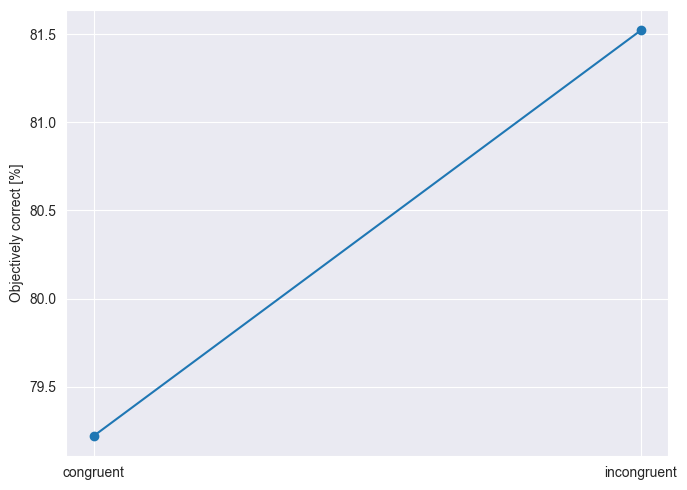

In [7]:
# Remove first trials after a reversal
last_blocks_results['time_since_reversal'] = (
    last_blocks_results.groupby((last_blocks_results['probability_condition'] != last_blocks_results['probability_condition'].shift()).cumsum())
      .cumcount()
)
last_blocks_results = last_blocks_results[last_blocks_results['time_since_reversal'] != 0]

# Splitting the dataframe into the two congruent blocks
dataframe_1 = last_blocks_results[last_blocks_results['congruency'] == 'congruent']
dataframe_1 = dataframe_1.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_1 = dataframe_1['objectively_correct_boolean'].dropna().tolist()
congruent_score = list_1[0] * 100
dataframe_2 = last_blocks_results[last_blocks_results['congruency'] == 'incongruent']
dataframe_2 = dataframe_2.groupby(['subject_id', 'session'])['objectively_correct_boolean'].mean().reset_index()
list_2 = dataframe_2['objectively_correct_boolean'].dropna().tolist()
incongruent_score = list_2[0] * 100

# Plot data
fig, ax = plt.subplots(figsize=(7, 5))
subject_data = pd.DataFrame.from_dict({'x': [1, 2], 'data': [congruent_score, incongruent_score]})
plt.plot(subject_data['x'], subject_data['data'], marker='o')

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['congruent', 'incongruent'])  # Set text labels.
plt.ylabel('Objectively correct [%]')
plot_name = 'all_trials_objective_performance_congruency'

# Show plot
plt.tight_layout()
plt.show()

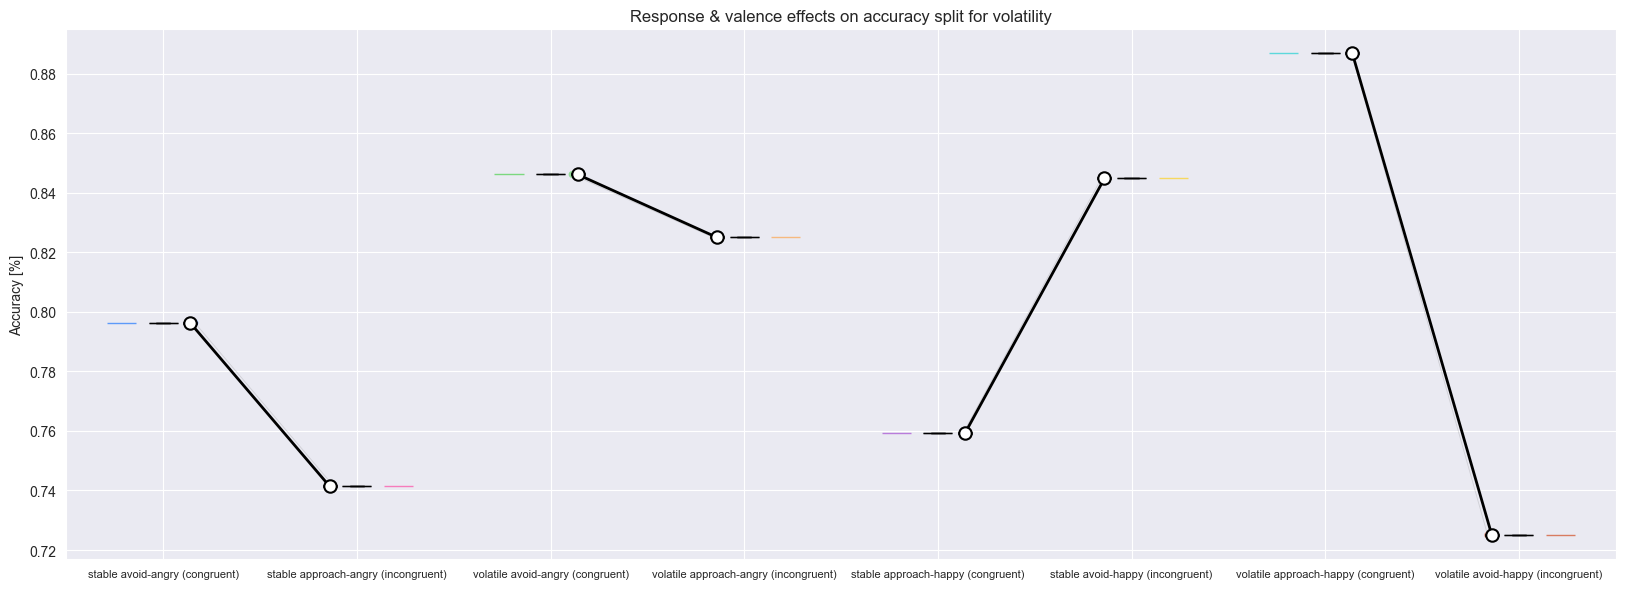

In [8]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe
    .pivot_table(
        index=['subject_id'],
        columns=['volatility', 'most_rewarding_response', 'valence'],
        values='objectively_correct_boolean',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted.columns = [
    '_'.join(str(x) for x in col if x)
    for col in combined_results_pivoted.columns
]

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
             'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
    labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
            'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
    flip=['left','right','left','right','left','right','left','right'],
    connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
    ylabel_name='Accuracy [%]',
    save=False,
    plot_name='Response & valence effects on accuracy split for volatility'
);

In [9]:
# Make performance cutoffs asymmetrical
if congruent_score >= incongruent_score:
    highest_score = congruent_score
    lowest_score = incongruent_score
elif congruent_score < incongruent_score:
    highest_score = incongruent_score
    lowest_score = congruent_score

# Calculate difference in cutoffs
cutoff_opposite = 100 - highest_score + 10

# Determine whether participant meets cutoff criteria
if highest_score < 60:
    print(f'Mean score for the highest condition {highest_score:.2f}% is below the 60% threshold.\n'
          'Exclude the participant.\n')
    participant_excluded = True
elif lowest_score < 40:
    print(f'Mean score for the lowest condition {lowest_score:.2f}% is below the 40% threshold.\n'
          'Exclude the participant.\n')
    participant_excluded = True
elif lowest_score < cutoff_opposite:
    print(f'Mean score for the lowest condition {lowest_score:.2f}% is below the threshold 100 - highest score + 10 ({cutoff_opposite:.2f}%).\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Mean score for the congruent condition {congruent_score:.2f}% and incongruent condition {incongruent_score:.2f}% fall within the cutoffs.\n'
    'Include the participant.\n')

Mean score for the congruent condition 79.22% and incongruent condition 81.52% fall within the cutoffs.
Include the participant.



# Responses over the entire experiment

/Volumes/kenvdzee/Documents/phd_1_analysis/utils/analysis_functions.py:208: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataframe[new_column] = dataframe[old_column].replace(mapping)


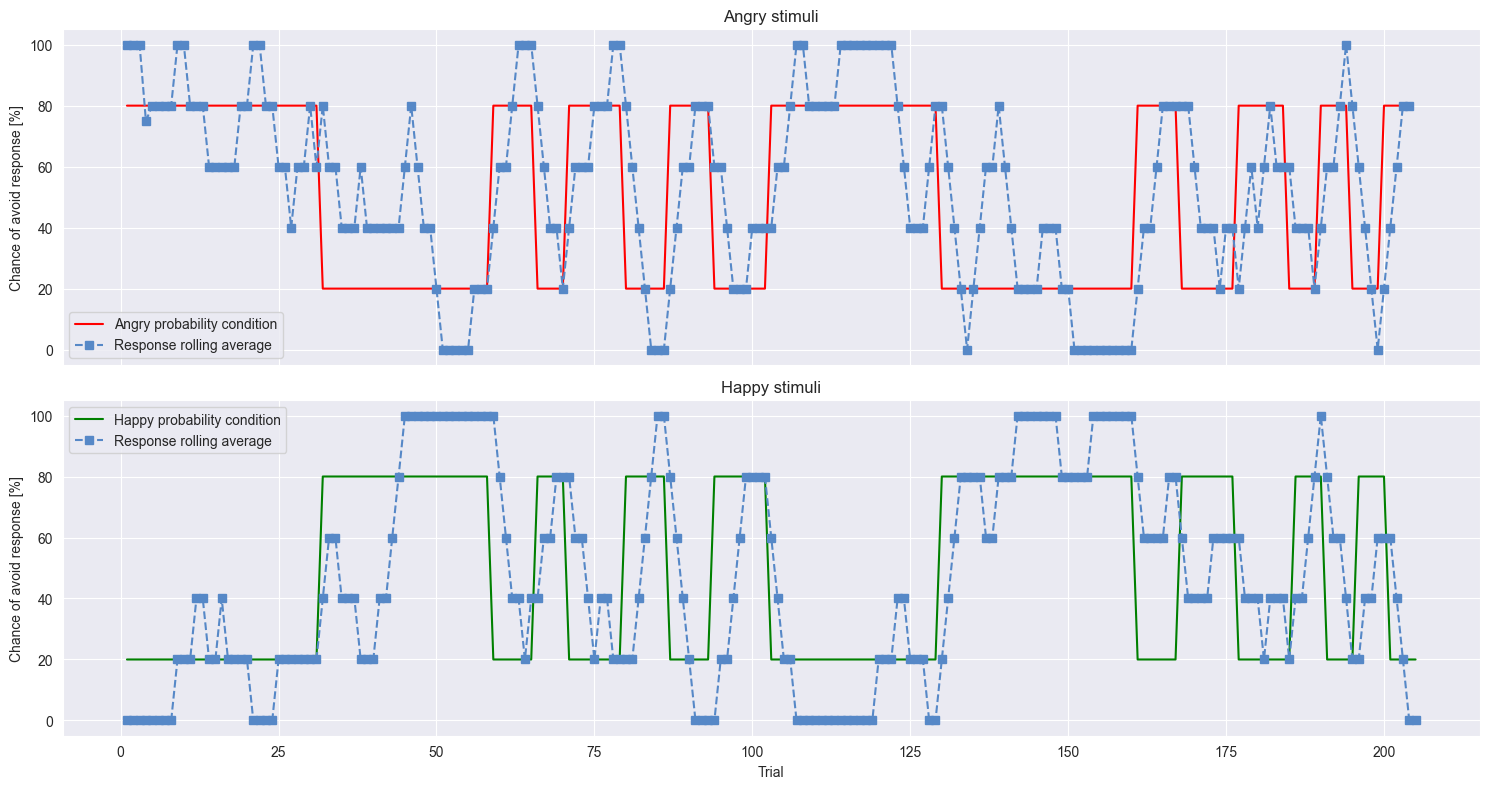

In [10]:
# Jitter vertically to make the lines easier to read when overlapping
dataframe = combined_results_dataframe.dropna(subset=['response'])
dataframe = dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'])
dataframe['trial_separated'] = (
    dataframe
    .groupby(['subject_id', 'session', 'stimuli_type'])
    .cumcount()
    + 1
)
dataframe = utils.analysis_functions.replace_strings_with_integers(dataframe,
                                                                                    {'avoid': 100, 'approach': 0},
                                                                                    'response',
                                                                                    'response_int')
dataframe['response_rolling_average'] = (
    dataframe
    .groupby('stimuli_type')['response_int']
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean())
)

stimuli_list = ['Angry', 'Happy']
colour_list = ['red', 'green']

stim_types = dataframe['stimuli_type'].unique()
n_types = len(stim_types)

# create one subplot per stimuli_type
fig, axes = plt.subplots(n_types, 1,
                         figsize=(15, 4 * n_types),
                         sharex=True)

# if there's only one type, axes is not a list
if n_types == 1:
    axes = [axes]

for ax, stim in zip(axes, stim_types):
    sub = dataframe[dataframe['stimuli_type'] == stim]
    ax.plot(sub['trial_separated'], sub['probability_condition'], linestyle='-',
            label=f'{stimuli_list[stim-1]} probability condition', color=colour_list[stim-1])
    ax.plot(sub['trial_separated'], sub['response_rolling_average'],
            marker='s', linestyle='--',
            label='Response rolling average', color='#5688C7')
    ax.set_title(f'{stimuli_list[stim-1]} stimuli')
    ax.set_ylabel('Chance of avoid response [%]')
    ax.legend(loc='best')

# common x-axis label
axes[-1].set_xlabel('Trial')

plt.tight_layout()
plt.show()

# Reaction time check

In [11]:
# Re-import data with the invalid trials to check RT effects
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, remove_invalid_trials=False)

# Print percentage of non-response trials
non_response_trials = combined_results_dataframe[combined_results_dataframe['response'].isna()]
percentage_responses = len(non_response_trials)/len(combined_results_dataframe)*100

if percentage_responses > 10:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
      'This means that the participant responded in less than 90% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'{len(non_response_trials)} out of {len(combined_results_dataframe)} trials are non-response trials\n'
      f'So, {percentage_responses:.2f}% of the trials are non-response trials\n'
          'Include the participant.\n')

joystick_locked_trials = combined_results_dataframe[combined_results_dataframe['RT_s'] < 0.05]
percentage_joystick_locked = len(joystick_locked_trials)/len(combined_results_dataframe)*100

if percentage_joystick_locked > 10:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
      'This means that the participant locked the joystick in more than 10% of the trials.\n'
          'Exclude the participant.\n')
    participant_excluded = True
else:
    print(f'Participant locked the joystick in {len(joystick_locked_trials)} out of {len(combined_results_dataframe)} trials\n'
      f"That's {percentage_joystick_locked:.2f}% of the trials\n"
          'Include the participant.\n')

0 out of 444 trials are non-response trials
So, 0.00% of the trials are non-response trials
Include the participant.

Participant locked the joystick in 1 out of 444 trials
That's 0.23% of the trials
Include the participant.



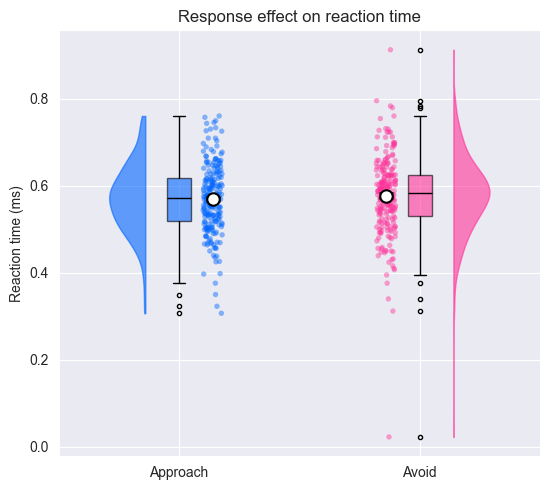

In [12]:
combined_results_pivoted = (
    combined_results_dataframe
    .groupby('response')['RT_s']
    .apply(lambda s: s.reset_index(drop=True))
    .unstack(level=0)
    .rename_axis(None, axis=1)
    .reset_index(drop=True)
)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['approach', 'avoid'],
    labels=['Approach', 'Avoid'],
    flip=['left','right'],
    ylabel_name='Reaction time (ms)',
    plot_name='Response effect on reaction time',
    connect_pairs=False,
    save=False
);

In [13]:
if participant_excluded:
    raise Exception('Participant excluded on behavioural criteria')

# Check simulation safety criteria

In [14]:
simulation_directory = f'/Volumes/project/3025011.02/TUS_simulations/planning/'
stimulation_limits_exceeded = False

stimulation_output_full_filenames_1 = os.path.join(simulation_directory, '**', '*layered_output_table_target_1*.csv')
stimulation_output_full_filenames_2 = os.path.join(simulation_directory, '**', '*layered_output_table_target_2*.csv')
stimulation_output_full_filenames_3 = os.path.join(simulation_directory, '**', '*layered_output_table_target_3*.csv')

simulation_output_full_filenames = glob.glob(stimulation_output_full_filenames_1, recursive=True) + glob.glob(stimulation_output_full_filenames_2, recursive=True) + glob.glob(stimulation_output_full_filenames_3, recursive=True)

simulation_output_full_filenames = [s for s in simulation_output_full_filenames if f'sub-{unique_subject_ids[0]:03}' in s]
if not simulation_output_full_filenames:
    raise Exception('No simulations found')
simulation_output_full_filenames.sort()
print(simulation_output_full_filenames)

['/Volumes/project/3025011.02/TUS_simulations/planning/target_1_1/sub-039/sub-039_layered_output_table_target_1_1_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_2/sub-039/sub-039_layered_output_table_target_1_2_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_3/sub-039/sub-039_layered_output_table_target_1_3_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_4/sub-039/sub-039_layered_output_table_target_1_4_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_5/sub-039/sub-039_layered_output_table_target_1_5_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_1_6/sub-039/sub-039_layered_output_table_target_1_6_dc20_strength_2.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/target_2_1/sub-039/sub-039_layered_output_table_target_2_1_dc20_strength_3.csv', '/Volumes/project/3025011.02/TUS_simulations/planning/

### Check if target names are missing

In [15]:
expected = [f"target_{i}_{j}"
            for i in range(1, 4)
            for j in range(1, 7)]

# find which expected names are missing
missing = [t for t in expected
           if not any(t in filename for filename in simulation_output_full_filenames)]

if missing:
    print("Missing target names:")
    for name in missing:
        print("  -", name)
else:
    print("All target names 1_1 through 3_6 are present.")

All target names 1_1 through 3_6 are present.


In [16]:
# List to hold individual dataframes
list_of_dataframes = []

# Process each CSV file
for simulation_output_full_filename in simulation_output_full_filenames:
    # Extract the filename (without the path)
    stimulation_output_filename = os.path.basename(simulation_output_full_filename)
    # Remove the '.csv' extension
    stimulation_output_filename_without_extension = os.path.splitext(stimulation_output_filename)[0]

    # Split the filename by underscores
    stimulation_output_filename_parts = stimulation_output_filename_without_extension.split('_')

    # Extract the subject_id and target from the filename parts
    subject_id = stimulation_output_filename_parts[0]
    target = '_'.join(stimulation_output_filename_parts[4:7])

    # Read the CSV file (assuming it contains one row)
    try:
        df = pd.read_csv(simulation_output_full_filename)
    except Exception as e:
        print(f"Error reading {simulation_output_full_filename}: {e}")
        continue  # Skip this file if there's an error

    # Add the intensity and duty cycle based on the filename parts
    df['target'] = target
    if 'target_3' in target:
        df['intensity'] = 'strength_1'
        df['duty_cycle'] = 'dc20'
    else:
        duty_cycle = stimulation_output_filename_parts[7]
        intensity = '_'.join(stimulation_output_filename_parts[8:10])
        df['intensity'] = intensity
        df['duty_cycle'] = duty_cycle

    # Append the dataframe to the list
    list_of_dataframes.append(df)

# Combine all dataframes into one
if list_of_dataframes:
    stimulation_output = pd.concat(list_of_dataframes, ignore_index=True)
    print(stimulation_output)
else:
    raise Exception("No CSV files were found or processed.")

    subject_id  max_Isppa  max_Isppa_after_exit_plane  real_focal_distance  \
0           39   35.49130                    16.34630             1.500000   
1           39   28.20338                    13.94421             3.000000   
2           39   35.49130                    16.34630             1.500000   
3           39   28.20338                    13.94421             3.000000   
4           39   35.49130                    16.34630             1.500000   
5           39   28.20338                    13.94421             3.000000   
6           39   17.25451                    12.26865             6.041523   
7           39   13.88358                    10.35072             0.000000   
8           39   16.54203                    13.49591             7.500000   
9           39   14.66453                    10.85953             8.015610   
10          39   19.04701                    13.47853             5.000000   
11          39   18.45634                    10.99360           

In [17]:
# Reorder columns
column_indices = list(range(stimulation_output.shape[1]))
reordered_column_indices = [column_indices[0]] + column_indices[-3:] + column_indices[1:-3]
stimulation_output = stimulation_output.iloc[:, reordered_column_indices]
stimulation_output.sort_values(by=['subject_id', 'target', 'intensity', 'duty_cycle'], inplace=True)
stimulation_output.reset_index(drop=True, inplace=True)
stimulation_output['CEM43_brain_skin'] = stimulation_output[['CEM43_brain', 'CEM43_skin']].max(axis=1)
# Replace values to improve readability
stimulation_output['duty_cycle'] = stimulation_output['duty_cycle'].map({'dc10': '10%', 'dc15': '15%', 'dc20': '20%'})
stimulation_output['intensity'] = stimulation_output['intensity'].map({'strength_1': '35', 'strength_2': '63', 'strength_3': '81', 'strength_4': '110'})
# Now drop some columns
stimulation_output.drop(
    ['real_focal_distance','Ix_brain', 'Iy_brain','Iz_brain',
     'riseT_brain', 'riseT_skull', 'riseT_skin','isppa_at_target',
     'max_Isppa','half_max_ISPPA_volume_brain','avg_isppa_around_target',
     'focus_pos_final_1', 'focus_pos_final_2', 'focus_pos_final_3',
     'trans_pos_final_1', 'trans_pos_final_2', 'trans_pos_final_3'],
    axis=1,
    inplace=True
)

print(stimulation_output)

    subject_id      target intensity duty_cycle  max_Isppa_after_exit_plane  \
0           39  target_1_1        63        20%                    16.34630   
1           39  target_1_2        63        20%                    13.94421   
2           39  target_1_3        63        20%                    16.34630   
3           39  target_1_4        63        20%                    13.94421   
4           39  target_1_5        63        20%                    16.34630   
5           39  target_1_6        63        20%                    13.94421   
6           39  target_2_1        81        20%                    12.26865   
7           39  target_2_2        81        20%                    10.35072   
8           39  target_2_3        81        20%                    13.49591   
9           39  target_2_4        81        20%                    10.85953   
10          39  target_2_5        81        20%                    13.47853   
11          39  target_2_6        81        20%     

In [18]:
# ---- Limits ----
MI_skin = MI_brain = MI_skull = 1.9
pressure_max = 2e6
# To be conservative, we use the original values for CEM43
CEM_43_skin = CEM_43_skull = CEM_43_brain = 0.25
maxT_skin = maxT_skull = maxT_brain = 39
modulation_T_brain = 38

# ---- Helper: return {col: value} for columns exceeding their limit ----
def exceeded_tissues(row, limits):
    return {col: row[col] for col, lim in limits.items() if row[col] > lim}

def describe(row):
    return f"{row['target']} with an intensity of {row['intensity']}W/cm2 and a duty_cycle of {row['duty_cycle']}"

MI_limits       = {'max_MI_skin': MI_skin, 'max_MI_brain': MI_brain, 'max_MI_skull': MI_skull}
pressure_limits = {'max_pressure_skin': pressure_max, 'max_pressure_brain': pressure_max, 'max_pressure_skull': pressure_max}
CEM43_limits    = {'CEM43_skin': CEM_43_skin, 'CEM43_brain': CEM_43_brain, 'CEM43_skull': CEM_43_skull}
maxT_limits     = {'maxT_skin': maxT_skin, 'maxT_skull': maxT_skull, 'maxT_brain': maxT_brain}

# ---- Build masks ----
MI_mask          = (stimulation_output[list(MI_limits)]       > pd.Series(MI_limits)).any(axis=1)
pressure_mask    = (stimulation_output[list(pressure_limits)] > pd.Series(pressure_limits)).any(axis=1)
temperature_mask = (stimulation_output[list(maxT_limits)]     > pd.Series(maxT_limits)).any(axis=1)
thermal_modulation_mask = stimulation_output['maxT_brain'] > modulation_T_brain

# ---- Report MI ----
for _, row in stimulation_output[MI_mask].iterrows():
    print(f"{describe(row)}, exceeded the MI limits in the following tissues: {exceeded_tissues(row, MI_limits)}")
    stimulation_limits_exceeded = True

# ---- Report pressure (display in MPa) ----
for _, row in stimulation_output[pressure_mask].iterrows():
    exceeded = {col: val / 1e6 for col, val in exceeded_tissues(row, pressure_limits).items()}
    print(f"{describe(row)}, exceeded the pressure limits (MPa) in the following tissues: {exceeded}")
    stimulation_limits_exceeded = True

# ---- Report temperature-gated CEM43 (maxT itself is not reported) ----
for _, row in stimulation_output[temperature_mask].iterrows():
    exceeded_CEM = exceeded_tissues(row, CEM43_limits)
    if exceeded_CEM:
        print(f"{describe(row)}, exceeded the CEM43 limits in the following tissues: {exceeded_CEM}")
        stimulation_limits_exceeded = True

# ---- Report thermal modulation ----
for _, row in stimulation_output[thermal_modulation_mask].iterrows():
    exceeded = exceeded_tissues(row, {'maxT_brain': modulation_T_brain})
    print(f"{describe(row)}, might cause heating neuromodulation in the following tissues: {exceeded}")

target_2_2 with an intensity of 81W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.57436}
target_3_2 with an intensity of 35W/cm2 and a duty_cycle of 20%, might cause heating neuromodulation in the following tissues: {'maxT_brain': 38.17064}


# ITRUSST consensus on biophysical safety for transcranial ultrasound stimulation
For mechanical effects, it is non-significant risk if the mechanical index (MI) or the mechanical index for transcranial application (MItc) does not exceed 1.9.

For thermal effects, it is non-significant risk if any of the following three levels are met:
- The peak temperature rise does not exceed 2 ◦C
- The peak absolute temperature does not exceed 39 ◦C, assuming a baseline temperature of 37 ◦C
- The thermal dose does not exceed 2 CEM43 in brain tissue, 16 CEM43 in bone tissue, and 21 CEM43 in skin tissue
- The thermal dose does not exceed specific values of the thermal index (TI).

In [19]:
if participant_excluded:
    raise Exception('\nParticipant excluded on behavioural criteria.')
elif stimulation_limits_exceeded:
    raise Exception('\nParticipant exceeds stimulation thresholds.\nCheck whether you meet the safety criteria stated above.')